# Secure Transaction Monitoring with Al-Based Classification (Vineeth)

## **Data Downloading**

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kartik2112/fraud-detection

In [ ]:
!unzip -q fraud-detection.zip

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

## **Data Loading & Sampling**

In [2]:
df_train = pd.read_csv('fraudTrain.csv')
df = df_train.sample(frac=0.10, random_state=42).reset_index(drop=True)
print(df.shape)

(129668, 23)


## **Exploratory Data Analysis (EDA)**

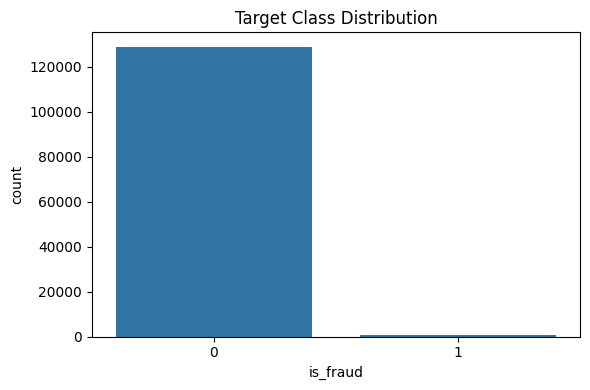

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title('Target Class Distribution')
plt.tight_layout()
plt.show()

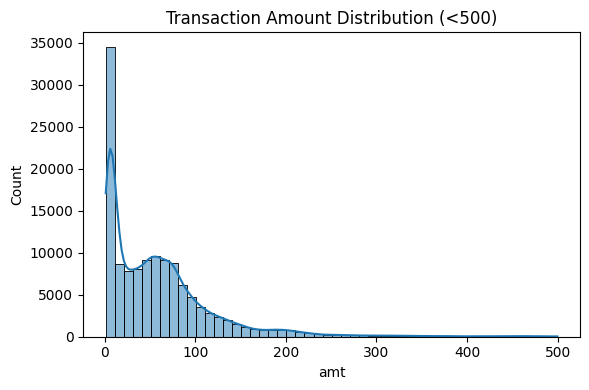

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(df[df['amt'] < 500]['amt'], bins=50, kde=True)
plt.title('Transaction Amount Distribution (<500)')
plt.tight_layout()
plt.show()

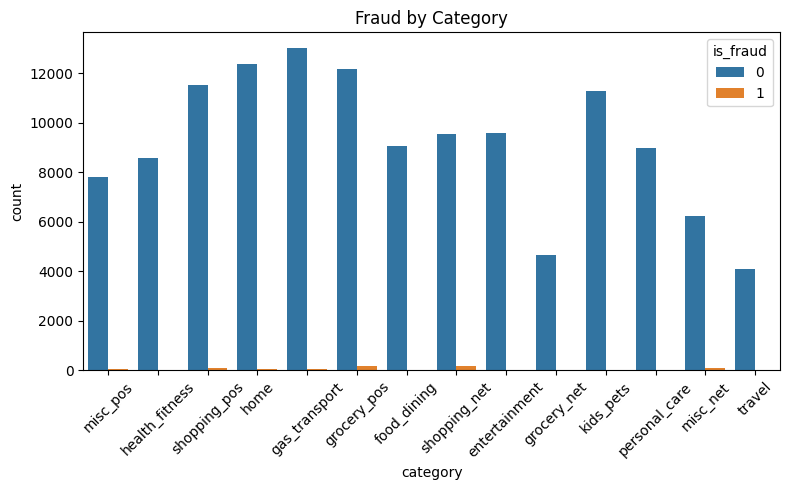

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='category', hue='is_fraud', data=df)
plt.title('Fraud by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

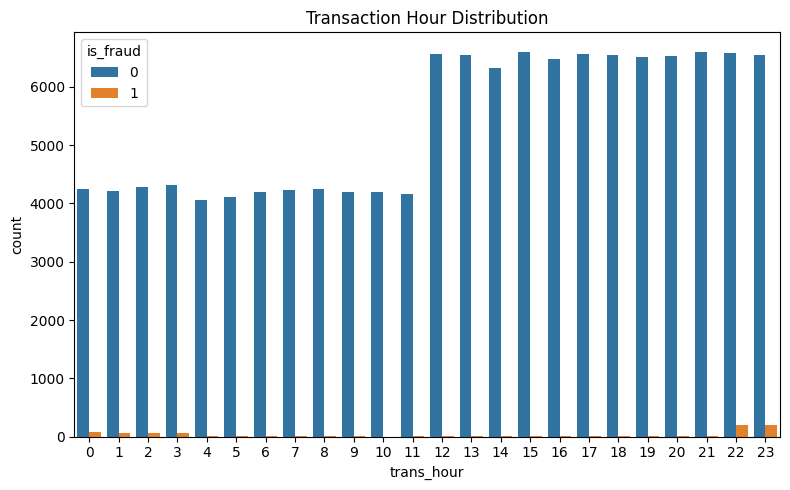

In [6]:
df_eda = df.copy()
df_eda['trans_hour'] = pd.to_datetime(df_eda['trans_date_trans_time']).dt.hour

plt.figure(figsize=(8,5))
sns.countplot(x='trans_hour', hue='is_fraud', data=df_eda)
plt.title('Transaction Hour Distribution')
plt.tight_layout()
plt.show()

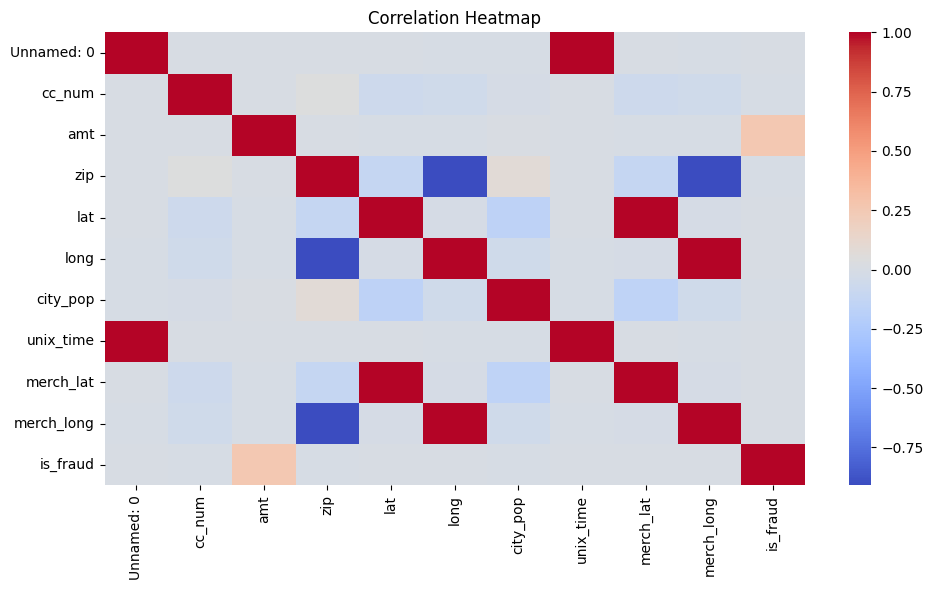

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## **Preprocessing & Feature Engineering**

In [8]:
data = df.copy()
data['datetime'] = pd.to_datetime(data['trans_date_trans_time'])
data['hour'] = data['datetime'].dt.hour
data['dayofweek'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month
features = ['amt', 'category', 'gender', 'state', 'city_pop', 'hour', 'dayofweek', 'month']
X = data[features]
y = data['is_fraud']
X = pd.get_dummies(X, columns=['category', 'gender', 'state'], drop_first=True)
print('Features processed:', X.shape)

Features processed: (129668, 68)


## **Train / Test Split & SMOTE**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

## **Model Building**

In [10]:
models = {}
models['AdaBoost'] = AdaBoostClassifier(random_state=42)
models['LightGBM'] = LGBMClassifier(random_state=42)
models['K-Nearest Neighbors'] = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
trained_models = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train_resampled)
    trained_models[name] = model

Training AdaBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 103116, number of negative: 103116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 745
[LightGBM] [Info] Number of data points in the train set: 206232, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training K-Nearest Neighbors...


## **Model Evaluation (Base Models)**

In [11]:
def evaluate_models(model_dict, X_test, y_test):
    results = []
    for name, model in model_dict.items():
        y_pred = model.predict(X_test)
        results.append({'Model': name, 'Accuracy': accuracy_score(y_test, y_pred)*100, 'Precision': precision_score(y_test, y_pred)*100, 'Recall': recall_score(y_test, y_pred)*100, 'F1-Score': f1_score(y_test, y_pred)*100})
    return pd.DataFrame(results).round(2)
base_metrics = evaluate_models(trained_models, X_test_scaled, y_test)
base_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,AdaBoost,96.98,14.25,80.65,24.22
1,LightGBM,99.54,58.04,83.87,68.60
2,K-Nearest Neighbors,99.29,29.17,13.55,18.50


### **Confusion Matrices & ROC Curves**

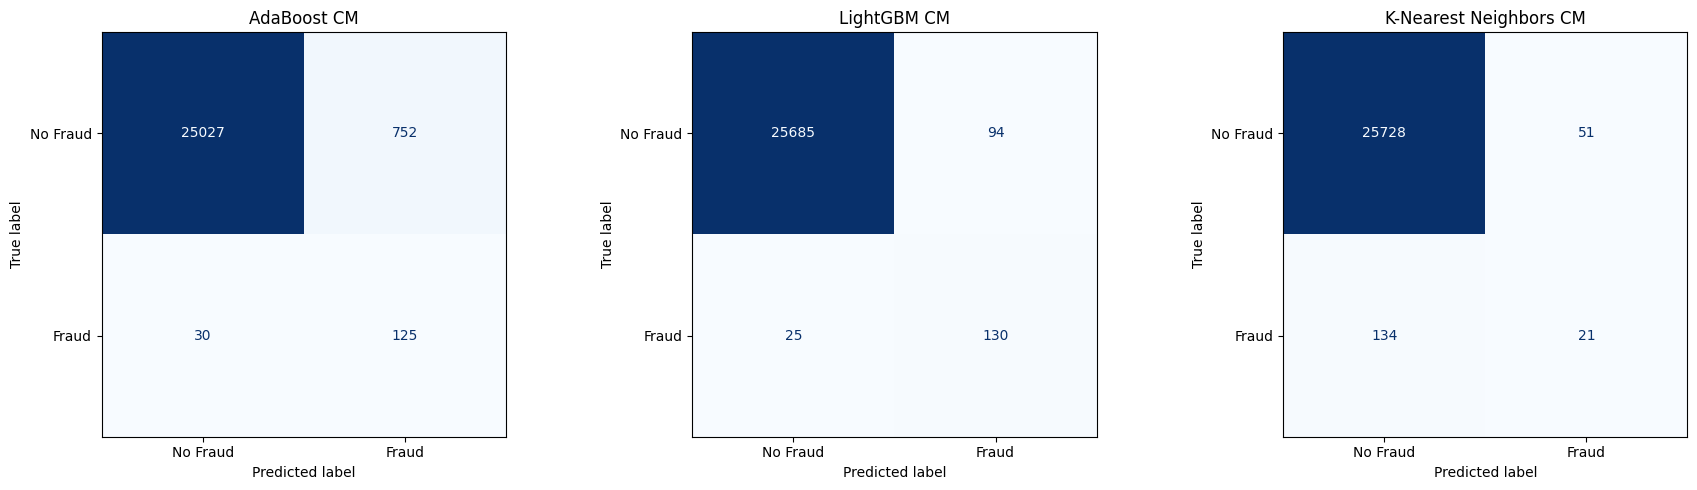

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(trained_models.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, model.predict(X_test_scaled)), display_labels=['No Fraud', 'Fraud'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name} CM')
plt.tight_layout()
plt.show()

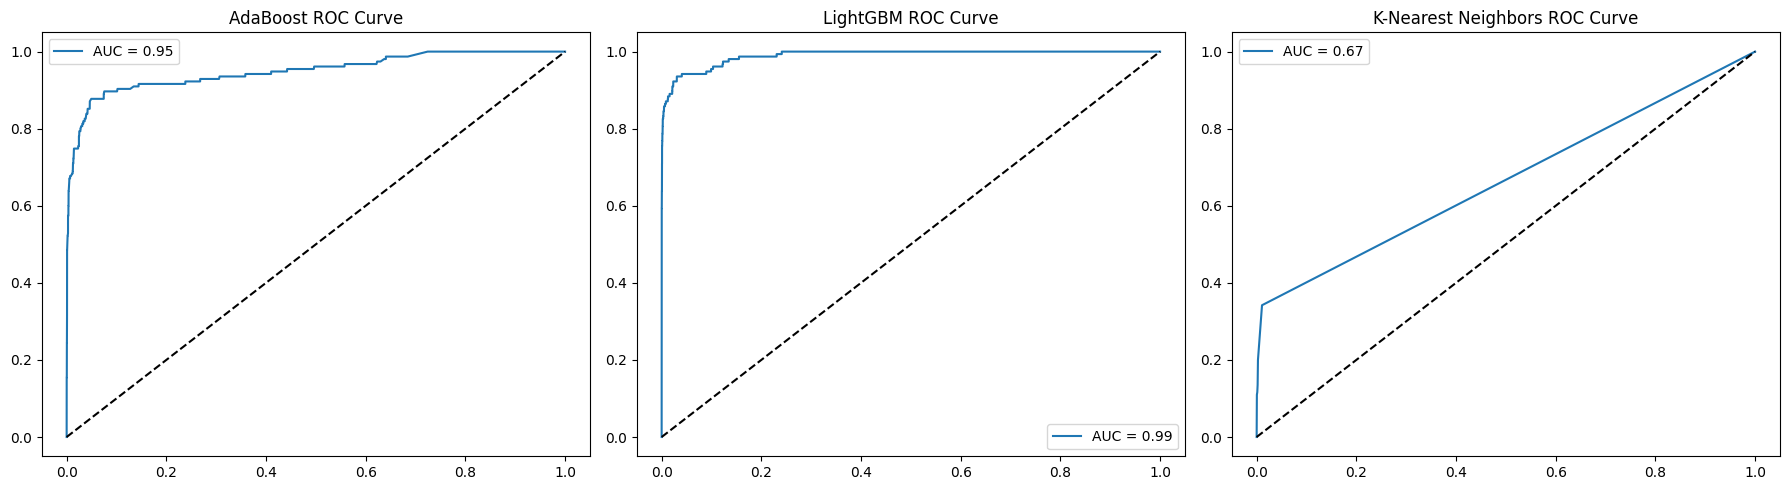

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(trained_models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[idx].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
    axes[idx].plot([0, 1], [0, 1], 'k--')
    axes[idx].set_title(f'{name} ROC Curve')
    axes[idx].legend()
plt.tight_layout()
plt.show()

## **Fine-Tuning Models**

In [14]:
param_grids = {'Logistic Regression': {'C': [0.1, 1, 10]}, 'Random Forest': {'n_estimators': [50, 100], 'max_depth': [10, 20]}, 'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.2]}, 'Decision Tree': {'max_depth': [10, 50, None]}, 'Gaussian Naive Bayes': {'var_smoothing': np.logspace(0,-9, num=10)}, 'XGBoost': {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.2]}, 'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}, 'LightGBM': {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.2]}, 'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7]}}
fine_tuned_models = {}
for name, model in models.items():
    print(f'Fine-tuning {name}...')
    rs = RandomizedSearchCV(model, param_grids[name], n_iter=3, cv=3, scoring='f1', n_jobs=-1, random_state=42)
    rs.fit(X_train_scaled, y_train_resampled)
    fine_tuned_models[name] = rs.best_estimator_

Fine-tuning AdaBoost...
Fine-tuning LightGBM...
[LightGBM] [Info] Number of positive: 103116, number of negative: 103116
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 745
[LightGBM] [Info] Number of data points in the train set: 206232, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fine-tuning K-Nearest Neighbors...


## **Tuned Evaluation**

In [15]:
tuned_metrics = evaluate_models(fine_tuned_models, X_test_scaled, y_test)
tuned_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,AdaBoost,96.99,14.37,81.29,24.42
1,LightGBM,99.71,74.23,78.06,76.10
2,K-Nearest Neighbors,99.35,39.06,16.13,22.83


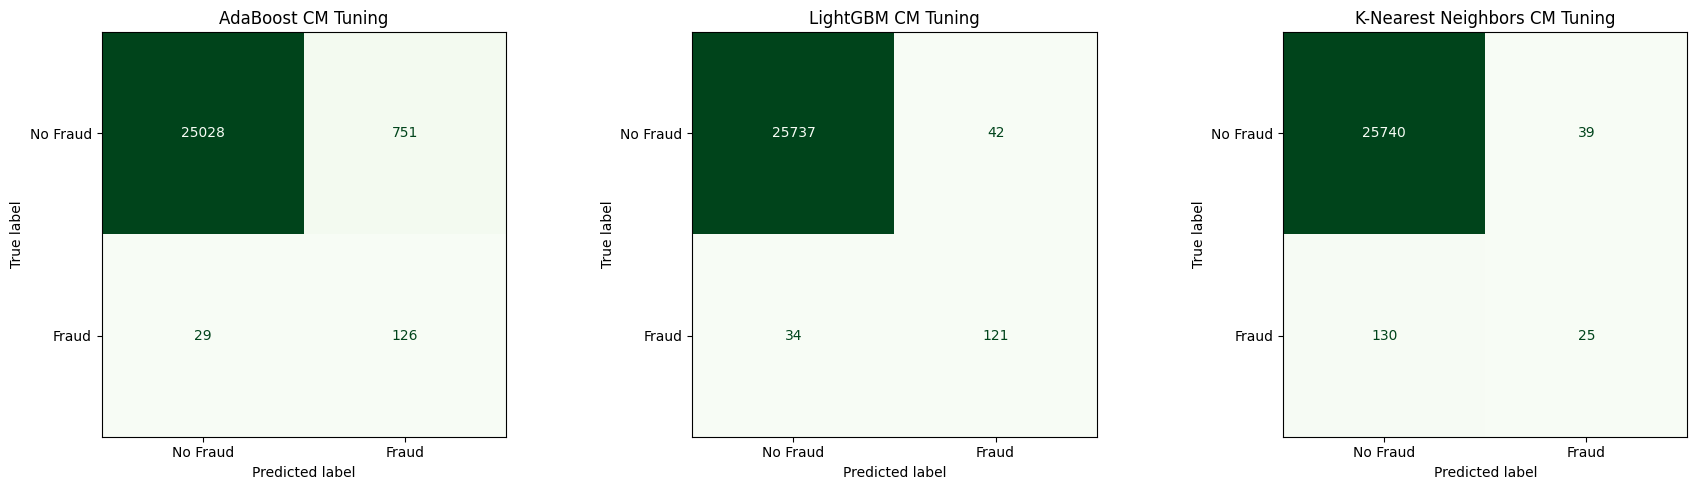

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(fine_tuned_models.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, model.predict(X_test_scaled)), display_labels=['No Fraud', 'Fraud'])
    disp.plot(ax=axes[idx], cmap='Greens', colorbar=False)
    axes[idx].set_title(f'{name} CM Tuning')
plt.tight_layout()
plt.show()

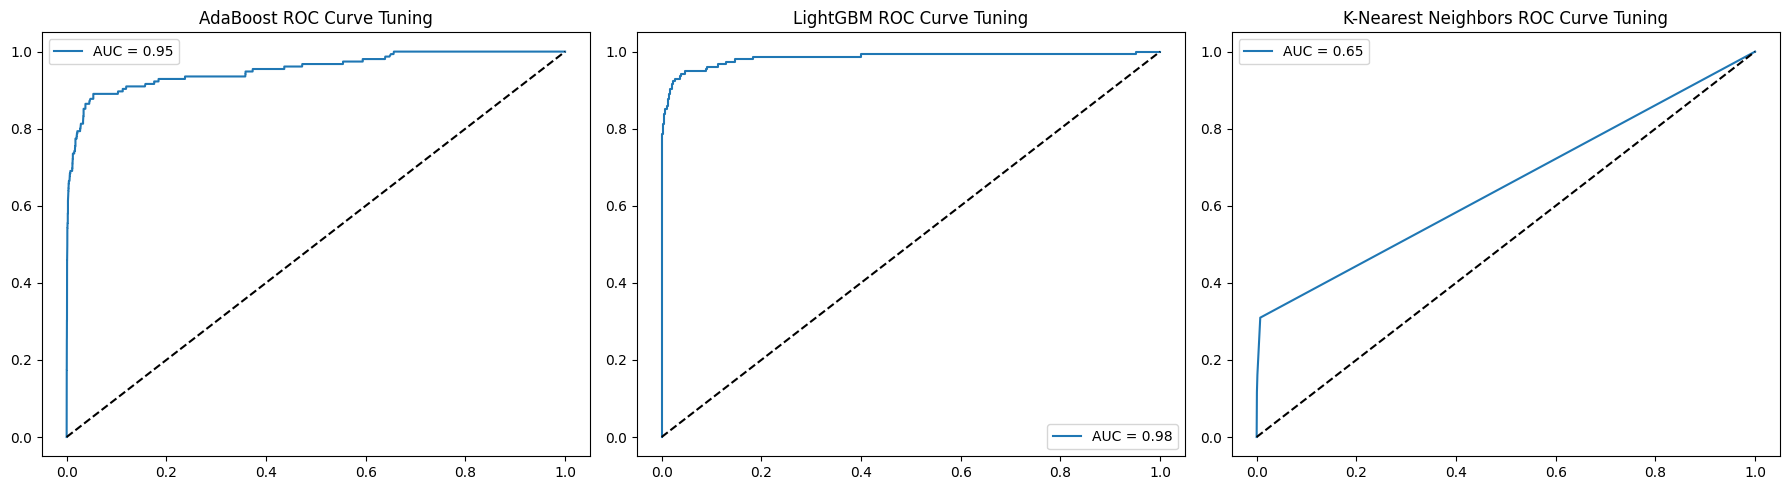

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(fine_tuned_models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[idx].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
    axes[idx].plot([0, 1], [0, 1], 'k--')
    axes[idx].set_title(f'{name} ROC Curve Tuning')
    axes[idx].legend()
plt.tight_layout()
plt.show()

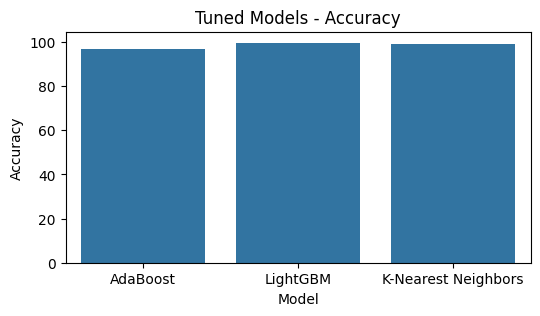

In [18]:
plt.figure(figsize=(6,3))
sns.barplot(x='Model', y='Accuracy', data=tuned_metrics)
plt.title('Tuned Models - Accuracy')
plt.show()

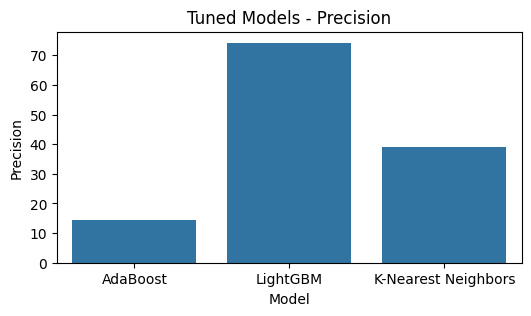

In [19]:
plt.figure(figsize=(6,3))
sns.barplot(x='Model', y='Precision', data=tuned_metrics)
plt.title('Tuned Models - Precision')
plt.show()

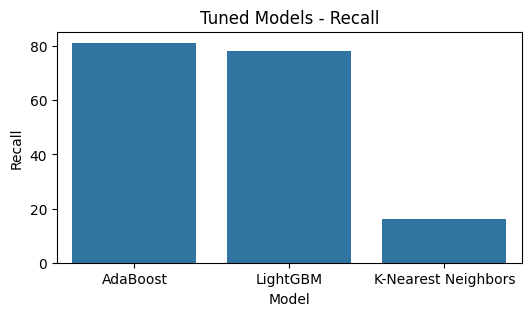

In [20]:
plt.figure(figsize=(6,3))
sns.barplot(x='Model', y='Recall', data=tuned_metrics)
plt.title('Tuned Models - Recall')
plt.show()

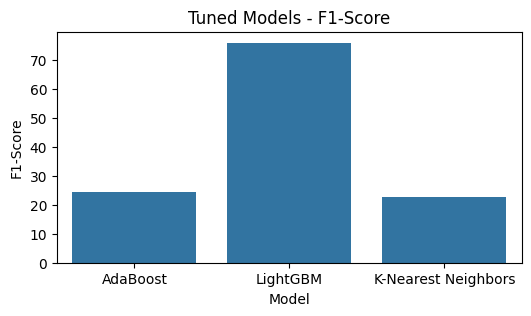

In [21]:
plt.figure(figsize=(6,3))
sns.barplot(x='Model', y='F1-Score', data=tuned_metrics)
plt.title('Tuned Models - F1-Score')
plt.show()

## **Test Prediction**

In [22]:
df_test = pd.read_csv('fraudTest.csv')
data_test = df_test.copy()
data_test['datetime'] = pd.to_datetime(data_test['trans_date_trans_time'])
data_test['hour'] = data_test['datetime'].dt.hour
data_test['dayofweek'] = data_test['datetime'].dt.dayofweek
data_test['month'] = data_test['datetime'].dt.month
X_unseen = pd.get_dummies(data_test[features], columns=['category', 'gender', 'state'], drop_first=True)
for col in X.columns:
    if col not in X_unseen.columns: X_unseen[col] = 0
X_unseen = X_unseen[X.columns]
X_unseen_scaled = scaler.transform(X_unseen)
best_name = tuned_metrics.loc[tuned_metrics['F1-Score'].idxmax(), 'Model']
best_model = fine_tuned_models[best_name]
test_preds = best_model.predict(X_unseen_scaled)
final_df = df_test[['trans_num', 'amt', 'category', 'is_fraud']].copy()
final_df.rename(columns={'is_fraud': 'Actual_Fraud'}, inplace=True)
final_df['Predicted_Fraud'] = test_preds
final_df['Prediction_Correct'] = (final_df['Actual_Fraud'] == final_df['Predicted_Fraud'])
final_df.head(20)

,trans_num,amt,category,Actual_Fraud,Predicted_Fraud,Prediction_Correct
0,2da90c7d74bd46a0caf3777415b3ebd3,2.86,personal_care,0,0,True
1,324cc204407e99f51b0d6ca0055005e7,29.84,personal_care,0,0,True
2,c81755dbbbea9d5c77f094348a7579be,41.28,health_fitness,0,0,True
3,2159175b9efe66dc301f149d3d5abf8c,60.05,misc_pos,0,0,True
4,57ff021bd3f328f8738bb535c302a31b,3.19,travel,0,0,True
5,798db04aaceb4febd084f1a7c404da93,19.55,kids_pets,0,0,True
6,17003d7ce534440eadb10c4750e020e5,133.93,health_fitness,0,0,True
7,8be473af4f05fc6146ea55ace73e7ca2,10.37,personal_care,0,0,True
8,71a1da150d1ce510193d7622e08e784e,4.37,shopping_pos,0,0,True
9,a7915132c7c4240996ba03a47f81e3bd,66.54,food_dining,0,0,True
